# Executive Exploratory Data Analysis

# 1. Executive Summary

Begin `EDA_Executive.ipynb` with an executive bullet point summary of your most novel and non-trivial findings.

A reader should understand your key conclusions in under one minute.

# 2. Data Retrieval

Load data using the official scripts and utilities provided in the template repository:

After running [`download_data.py`](download_data.py) (following the instructions in the root [`README.md`](README.md)), you can simply use `pandas` to read the CSV or Parquet files from your local `data/` directory (see [`eda_starter_template.py`](eda_starter_template.py) for an example).

Clearly state:

- What data sources you used
- Any preprocessing steps
- Assumptions or limitations

In this EDA, we use two main data sources:

- Coin Metrics BTC daily dataset (coinmetrics_btc.csv) for price and on-chain features.

- Polymarket finance & politics Parquet exports (markets, tokens, trades, odds history, event statistics, and summary files) to capture prediction market activity and pricing behavior.

In [26]:
import pandas as pd
import numpy as np
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 2.1 Coinmetrics

For the Coin Metrics dataset:

- We convert time to timezone-aware UTC timestamps and set it as the index.

- We restrict the sample period to 2018-01-01 to 2025-12-31 to ensure consistency with other datasets.

- We sort the data chronologically and confirm the index is strictly increasing and unique.

- We construct derived features including daily returns, log returns, 30-day annualized volatility, 200-day moving average, relative deviation from the 200DMA, and drawdown.

In [23]:
# Load Coin Metrics + Basic Cleaning
DATA_PATH = Path("../data/Coin Metrics/coinmetrics_btc.csv")

START = "2018-01-01"
END   = "2025-12-31"

df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")

df = (
    df[(df["time"] >= START) & (df["time"] <= END)]
      .sort_values("time")
      .set_index("time")
      .copy()
)

# Feature Engineering
px = df["PriceUSD"].astype(float)

# Returns
df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# 30-day annualized volatility
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200-day moving average
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# Drawdown
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1

df.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,2.027413e+07,241625.0,677625.0,4.860752e+09,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-02 00:00:00+00:00,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,2.027467e+07,343664.0,960051.0,8.485368e+09,0.095782,0.091468,NaN,NaN,NaN,0.0
2018-01-03 00:00:00+00:00,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,2.027516e+07,396942.0,1049679.0,8.041486e+09,0.017348,0.017200,NaN,NaN,NaN,0.0
2018-01-04 00:00:00+00:00,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,2.027568e+07,424762.0,1191394.0,1.138178e+10,0.003998,0.003990,NaN,NaN,NaN,0.0
2018-01-05 00:00:00+00:00,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,2.027613e+07,339441.0,1002989.0,1.288165e+10,0.127863,0.120324,NaN,NaN,NaN,0.0


# 2.2 Ploymarket

In [31]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from /Users/shuangshuang/Documents/GitHub/bitcoin-analytics-capstone-sp26-team08/data/Polymarket...
[Memory] Before loading Polymarket data: 46.34 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 229.40 MB (Δ 183.06 MB)
Data loaded successfully!


In [32]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"
trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)

if trades_path.exists():
    trades_df = pl.scan_parquet(trades_path).collect()
    
    # Fix timestamp corruption
    for col in trades_df.columns:
        if any(x in col.lower() for x in ["timestamp", "trade", "created_at", "end_date"]):
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                if not trades_df[col].is_empty() and trades_df[col].max() < datetime(2020, 1, 1):
                    trades_df = trades_df.with_columns((pl.col(col).cast(pl.Int64) * 1000).cast(pl.Datetime))
                    
            # Enforce 2020+ constraint (replace placeholders/zeros with null)
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                    trades_df = trades_df.with_columns(
                        pl.when(pl.col(col) < datetime(2020, 1, 1))
                        .then(None)
                        .otherwise(pl.col(col))
                        .alias(col)
                    )
                
    print(f"Loaded {len(trades_df)} trades records.")

In [33]:
df_markets
# Filter for rows where both are True
both_true = df_markets.filter(
    (pl.col("active") == True) & (pl.col("closed") == True)
)

print(f"Total Markets: {len(df_markets)}")
print(f"Markets with (active=True AND closed=True): {len(both_true)}")

Total Markets: 78321
Markets with (active=True AND closed=True): 73200


For Odds History, we did:
- Convert the timestamp field into a daily date format (timestamp → date).
- Filter the dataset to include only binary outcomes (Yes/No/Up/Down).
- Aggregate the data to a daily frequency at the market level.
- Construct derived indicators, such as the risk index and related volatility measures.
- Merge the processed Polymarket data with daily BTC price data for comparison and analysis.

In [41]:
#convert time
df_odds = df_odds.with_columns(
    pl.col("timestamp").dt.date().alias("date")
)
# Filter the dataset to include only binary outcomes (Yes/No/Up/Down)
df_tokens_simple = (
    df_tokens
    .with_columns(pl.col("outcome").str.to_lowercase().alias("outcome_lower"))
    .filter(
        pl.col("outcome_lower").is_in(["yes", "no", "up", "down"])
    )
)
df_odds_simple = df_odds.join(
    df_tokens_simple.select(["market_id", "token_id", "outcome"]),
    on=["market_id", "token_id"],
    how="inner"
)
# Aggregate the data to a daily
df_daily = (
    df_odds_simple
    .sort(["market_id", "date", "timestamp"])
    .group_by(["market_id", "date"])
    .agg([
        pl.col("price").last().alias("p_close"),
        pl.count().alias("update_count")
    ])
    .sort(["market_id", "date"])
)
# Construct the risk index and related volatility measures
df_daily = df_daily.with_columns(
    (pl.col("p_close") - pl.col("p_close").shift(1))
    .over("market_id")
    .alias("p_diff_1d")
)

df_daily = df_daily.with_columns(
    pl.col("p_diff_1d")
    .rolling_std(7)
    .over("market_id")
    .alias("p_vol_7d")
)
daily_index = (
    df_daily
    .group_by("date")
    .agg([
        pl.col("p_vol_7d").mean().alias("risk_index"),
        pl.col("p_diff_1d").mean().alias("prob_shift_index"),
        pl.col("update_count").mean().alias("attention_index"),
        pl.count().alias("num_markets")
    ])
    .sort("date")
)

/var/folders/85/jcyy_w7d4g5cdzprsfn0tngh0000gn/T/ipykernel_9385/4109457309.py:25: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("update_count")
/var/folders/85/jcyy_w7d4g5cdzprsfn0tngh0000gn/T/ipykernel_9385/4109457309.py:49: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_markets")


# 3. General Dataset Overview


Provide a high level understanding of the dataset.

Include:

- Data integrity checks
- Data types and ranges
- Missingness and completeness
- Descriptive statistics
- Initial exploratory visualizations

# 3.1 Coinmetrics

The Coin Metrics dataset contains 2,922 daily observations from 2018-01-01 to 2025-12-31. The time index is strictly increasing and contains no duplicate timestamps, indicating a clean and well-structured time series suitable for analysis.

In [24]:
# Basic integrity checks
print("Rows:", len(df))
print("Time range:", df.index.min(), "→", df.index.max())

print(df.index.is_monotonic_increasing)
print(df.index.is_unique)

print("\nMissing values (top 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Rows: 2922
Time range: 2018-01-01 00:00:00+00:00 → 2025-12-31 00:00:00+00:00
True
True

Missing values (top 10 columns):
ReferenceRate       2922
ReferenceRateETH    2922
ReferenceRateEUR    2922
ReferenceRateUSD    2922
CapMrktEstUSD        537
price_vs_ma200       199
ma_200               199
vol_30d               30
logret_1d              1
ret_1d                 1
dtype: int64


Most core price and on-chain variables show no missing values, which supports reliable time-series analysis. However, several ReferenceRate columns are completely empty and will not be used in further analysis. The variable CapMrktEstUSD contains partial missing values (around 18% of the sample), which may require special treatment if included in modeling. Overall, the dataset shows strong completeness for key variables such as price, transaction counts, and supply-related metrics.

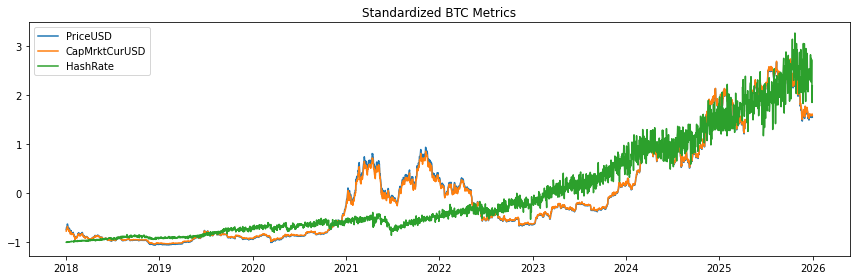

In [27]:
cols = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
scaled = StandardScaler().fit_transform(df[cols])

plt.figure(figsize=(12,4))
plt.plot(df.index, scaled)
plt.legend(cols)
plt.title("Standardized BTC Metrics")
plt.tight_layout()
plt.savefig("plots/Standardized BTC Metrics.png", dpi=300)
plt.show()

From 2018 to 2025, BTC price experienced clear cycles, including a decline after 2018, a strong bull market in 2020–2021, a sharp correction in 2022, and a recovery with higher volatility after 2023. Market Cap moved almost identically to price because it is mechanically calculated as price multiplied by circulating supply. In contrast, Hashrate showed a more structural upward trend. It increased gradually and steadily from 2018 to 2021, declined during 2021–2022 due to mining restrictions and the market downturn, and then resumed growth after 2022. After 2023, Hashrate growth accelerated with greater fluctuations, indicating stronger competition and increased investment in mining infrastructure.

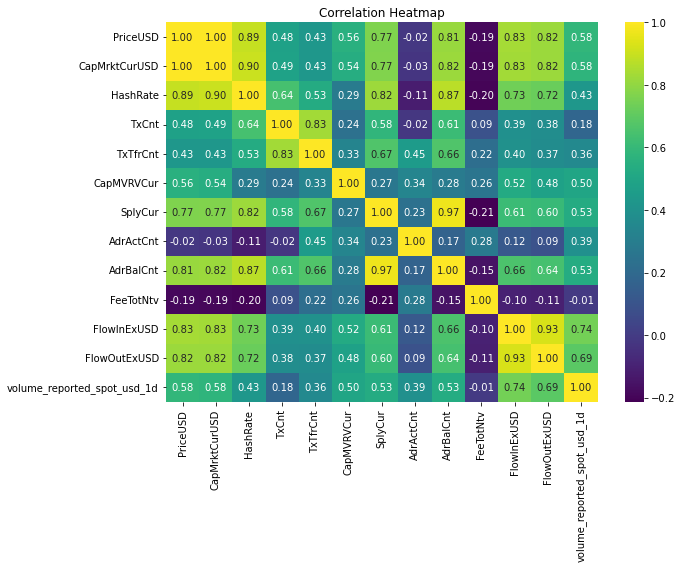

In [28]:
corr_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt", "TxTfrCnt",
    "CapMVRVCur", "SplyCur", "AdrActCnt", "AdrBalCnt",
    "FeeTotNtv", "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The correlation matrix shows that PriceUSD and CapMrktCurUSD are almost perfectly positively correlated, which is expected because market capitalization is mechanically calculated from price and circulating supply. SplyCur and AdrBalCnt are also highly correlated, reflecting the long-term growth of the network over time. FlowInExUSD and FlowOutExUSD show strong positive correlation, meaning that when the market is active, both inflows and outflows to exchanges tend to increase together, so their difference (net flow) may contain more noise. Many indicators, such as HashRate, AdrBalCnt, and exchange flows, are strongly correlated with price, suggesting that they mainly reflect overall bull and bear market trends. In contrast, AdrActCnt has almost no correlation with price, which means it may provide more independent information about on-chain activity. MVRV shows a moderate correlation with price, indicating that it is partly influenced by price movements but may also capture additional valuation-related information.

# 3.2 Ploymarket-odds history

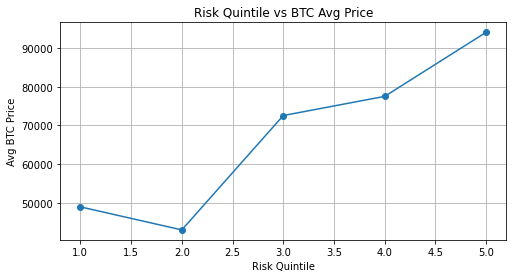

In [49]:
daily_pd = pd.DataFrame(daily_index.to_dict(as_series=False))
btc_pd = df.reset_index()[["time", "PriceUSD"]]

daily_pd["date"] = pd.to_datetime(daily_pd["date"]).dt.normalize()

btc_pd["time"] = (
    pd.to_datetime(btc_pd["time"], utc=True)  
      .dt.tz_convert(None)   
      .dt.normalize()
)

merged = daily_pd.merge(
    btc_pd,
    left_on="date",
    right_on="time",
    how="inner"
)
#Risk Quintile vs BTC Avg Price analysis
merged["risk_q5"] = pd.qcut(merged["risk_index"], 5, labels=[1,2,3,4,5])

risk_table = merged.groupby("risk_q5").agg(
    avg_btc_price=("PriceUSD","mean")
)

plt.figure(figsize=(8,4))
plt.plot(risk_table.index, risk_table["avg_btc_price"], marker="o")
plt.title("Risk Quintile vs BTC Avg Price")
plt.xlabel("Risk Quintile")
plt.ylabel("Avg BTC Price")
plt.grid(True)
plt.show()

From the this figure, we can clearly observe that as the Risk Quintile increases from group 1 to group 5, the average BTC price also increases steadily. In other words, higher levels of the risk index are associated with higher average BTC price levels.

This monotonic upward pattern suggests that, during the sample period, times with higher Polymarket risk index values tend to coincide with periods when BTC prices are relatively high. Put differently, higher risk levels often appear at the same time as higher BTC price levels.

However, it is important to note that this relationship likely reflects a phase-based co-movement rather than a direct causal effect. The increase in the risk index may be related to stronger market activity and higher uncertainty, which are also common during bullish market phases. Therefore, the simultaneous rise in both variables is more likely driven by overall market cycles, rather than the risk index directly causing changes in BTC prices.

# 4. Prediction Market Exploration

Perform a detailed analysis of the Polymarket prediction market data to evaluate its utility for Bitcoin accumulation strategies. This investigation must result in one of two formally justified outcomes:

1. **Could not discover use cases** for the purpose of improving Bitcoin accumulation models (but the investigation was informative).
2. **Discovered interesting use cases** for the purpose of improving Bitcoin accumulation models.

> **Note:** To identify accumulation signals, analyze prediction market data alongside on-chain and macro features. Do not evaluate prediction market utility in isolation; this EDA focuses on cross-feature relationships.

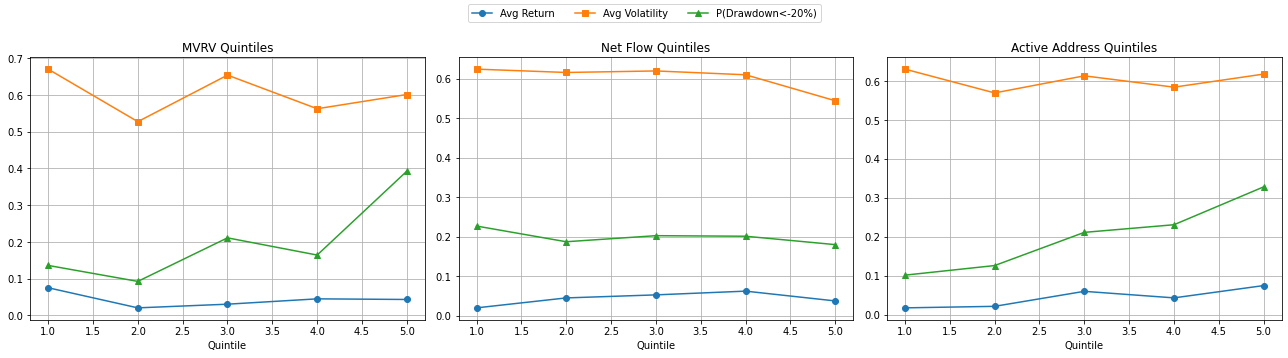

In [29]:
# Forward-looking performance conditioning analysis
# 1 Build forward-looking metrics
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

h = 30

# Forward 30-day return
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# Forward 30-day volatility (annualized)
logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Forward 30-day max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1

# Remove NaN
eda = df.dropna(subset=["fwd_ret_30d", 
                        "fwd_vol_30d", 
                        "fwd_min_dd_30d"]).copy()

# 2 Quintile grouping
# MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

# Net Flow
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

# Active Address
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
).reset_index()

# 3 visualization
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# MVRV
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["avg_fwd_ret_30d"], marker="o", label="Avg Return")
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["avg_fwd_vol_30d"], marker="s", label="Avg Volatility")
axes[0].plot(mvrv_table["mvrv_q5"], 
             mvrv_table["prob_dd_lt_20pct"], marker="^", label="P(Drawdown<-20%)")

axes[0].set_title("MVRV Quintiles")
axes[0].set_xlabel("Quintile")
axes[0].grid(True)

# Net Flow 
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["avg_fwd_ret_30d"], marker="o")
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["avg_fwd_vol_30d"], marker="s")
axes[1].plot(netflow_table["netflow_q5"], 
             netflow_table["prob_dd_lt_20pct"], marker="^")

axes[1].set_title("Net Flow Quintiles")
axes[1].set_xlabel("Quintile")
axes[1].grid(True)

# Active Address
axes[2].plot(adr_table["adract_q5"], 
             adr_table["avg_fwd_ret_30d"], marker="o")
axes[2].plot(adr_table["adract_q5"], 
             adr_table["avg_fwd_vol_30d"], marker="s")
axes[2].plot(adr_table["adract_q5"], 
             adr_table["prob_dd_lt_20pct"], marker="^")

axes[2].set_title("Active Address Quintiles")
axes[2].set_xlabel("Quintile")
axes[2].grid(True)


# Unified legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("plots/Forward_30D_Factor_Comparison.png",
            dpi=300, bbox_inches="tight")

plt.show()

We grouped MVRV, exchange net flow, and active address count into quintiles and examined the next 30-day return, volatility, and maximum drawdown to understand how different market conditions relate to future performance. The results show that when MVRV is at a low level, future 30-day average returns are higher, suggesting that a relatively undervalued state may offer better upside opportunities. In contrast, when MVRV is high, the average return is not necessarily the lowest, but the probability of large drawdowns increases significantly, indicating higher downside risk. For net flow, stronger exchange inflows are associated with a higher probability of large future declines, while stronger outflows correspond to lower downside risk, suggesting that net flow is more informative for risk than for return prediction. Regarding active address count, the relationship with future volatility is non-linear: both very low and very high activity levels can be associated with higher volatility. In addition, higher activity is linked to both higher average returns and higher drawdown risk, implying that market activity reflects overall market “heat,” where potential opportunities and risks increase together rather than moving in only one direction.

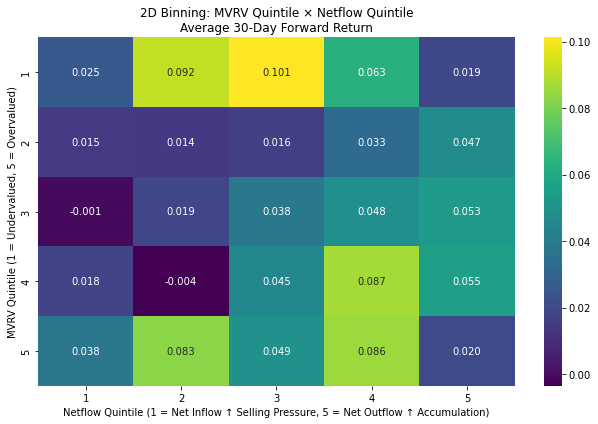

In [30]:
# 2D Binning: MVRV × Netflow
pivot = eda.pivot_table(
    index="mvrv_q5",
    columns="netflow_q5",
    values="fwd_ret_30d",
    aggfunc="mean"
)

plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return")
plt.xlabel("Netflow Quintile (1 = Net Inflow ↑ Selling Pressure, 5 = Net Outflow ↑ Accumulation)")
plt.ylabel("MVRV Quintile (1 = Undervalued, 5 = Overvalued)")

plt.tight_layout()
plt.savefig("plots/2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return.png", dpi=300, bbox_inches="tight")
plt.show()

We further examine whether future returns are higher when both valuation (MVRV) and capital flow behavior (Net Flow) fall into specific combinations. The two-dimensional grouping results show that when MVRV is in the lowest quintile (Q1, representing a relatively undervalued state) and Net Flow is in the middle-to-upper range (around Q2–Q3), the average 30-day forward return is the highest, approximately 9%–10%. This suggests that combining valuation and capital flow information provides better differentiation of future performance than using a single indicator alone. However, some combinations generate weak or even slightly negative returns, indicating that the relationship is not fully stable and may be influenced by broader market cycles or changing market conditions.